In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
import pandas as pd

data = {
    "Day": ["D1", "D2", "D3", "D4", "D5", "D6", "D7", "D8", "D9", "D10", "D11", "D12", "D13", "D14"],
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast", "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    "PlayTennis": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)
df.info
print(df.head())
print(df.shape)


  Day   Outlook  Temp Humidity    Wind PlayTennis
0  D1     Sunny   Hot     High    Weak         No
1  D2     Sunny   Hot     High  Strong         No
2  D3  Overcast   Hot     High    Weak        Yes
3  D4      Rain  Mild     High    Weak        Yes
4  D5      Rain  Cool   Normal    Weak        Yes
(14, 6)
    Day   Outlook  Temp Humidity    Wind PlayTennis
0    D1     Sunny   Hot     High    Weak         No
1    D2     Sunny   Hot     High  Strong         No
2    D3  Overcast   Hot     High    Weak        Yes
3    D4      Rain  Mild     High    Weak        Yes
4    D5      Rain  Cool   Normal    Weak        Yes
5    D6      Rain  Cool   Normal  Strong         No
6    D7  Overcast  Cool   Normal  Strong        Yes
7    D8     Sunny  Mild     High    Weak         No
8    D9     Sunny  Cool   Normal    Weak        Yes
9   D10      Rain  Mild   Normal    Weak        Yes
10  D11     Sunny  Mild   Normal  Strong        Yes
11  D12  Overcast  Mild     High  Strong        Yes
12  D13  Overcas

In [10]:
df.head()
# Define features and target variable

X = df.drop(['Day','PlayTennis'],axis=1)
Y = df['PlayTennis']

# One-hot encode the features
X = pd.get_dummies(X)
print(X)

    Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temp_Cool  Temp_Hot  \
0              False         False           True      False      True   
1              False         False           True      False      True   
2               True         False          False      False      True   
3              False          True          False      False     False   
4              False          True          False       True     False   
5              False          True          False       True     False   
6               True         False          False       True     False   
7              False         False           True      False     False   
8              False         False           True       True     False   
9              False          True          False      False     False   
10             False         False           True      False     False   
11              True         False          False      False     False   
12              True         False    

In [18]:
# Split the data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)

# Train the Decison Tree Classifier

# model = DecisionTreeClassifier(criterion='gini', max_depth= 3)
model = DecisionTreeClassifier(criterion='entropy')

model.fit(X_train,Y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

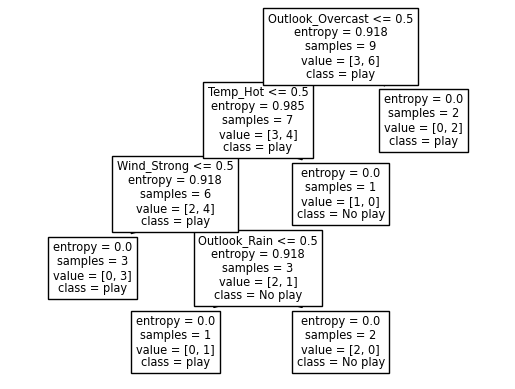

In [19]:
# visualize the tree

# plt.Figure(figsize=(25,20))
plot_tree(model, feature_names=X.columns, class_names= ['No play','play'])
plt.show()

In [20]:
y_pred = model.predict(X_test)
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[[1 1]
 [0 3]]
              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



# Random Forest Classifier


In [21]:
# Randdom forest Classifier

from sklearn.ensemble import RandomForestClassifier

In [31]:
# Train the random forest classifier 

model = RandomForestClassifier(n_estimators= 20, random_state= 42)

model.fit(X_train, Y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [32]:
# make prediction 

y_pred = model.predict(X_test)

In [33]:
#print confusion metrix and classigication report

print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[[1 1]
 [0 3]]
              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



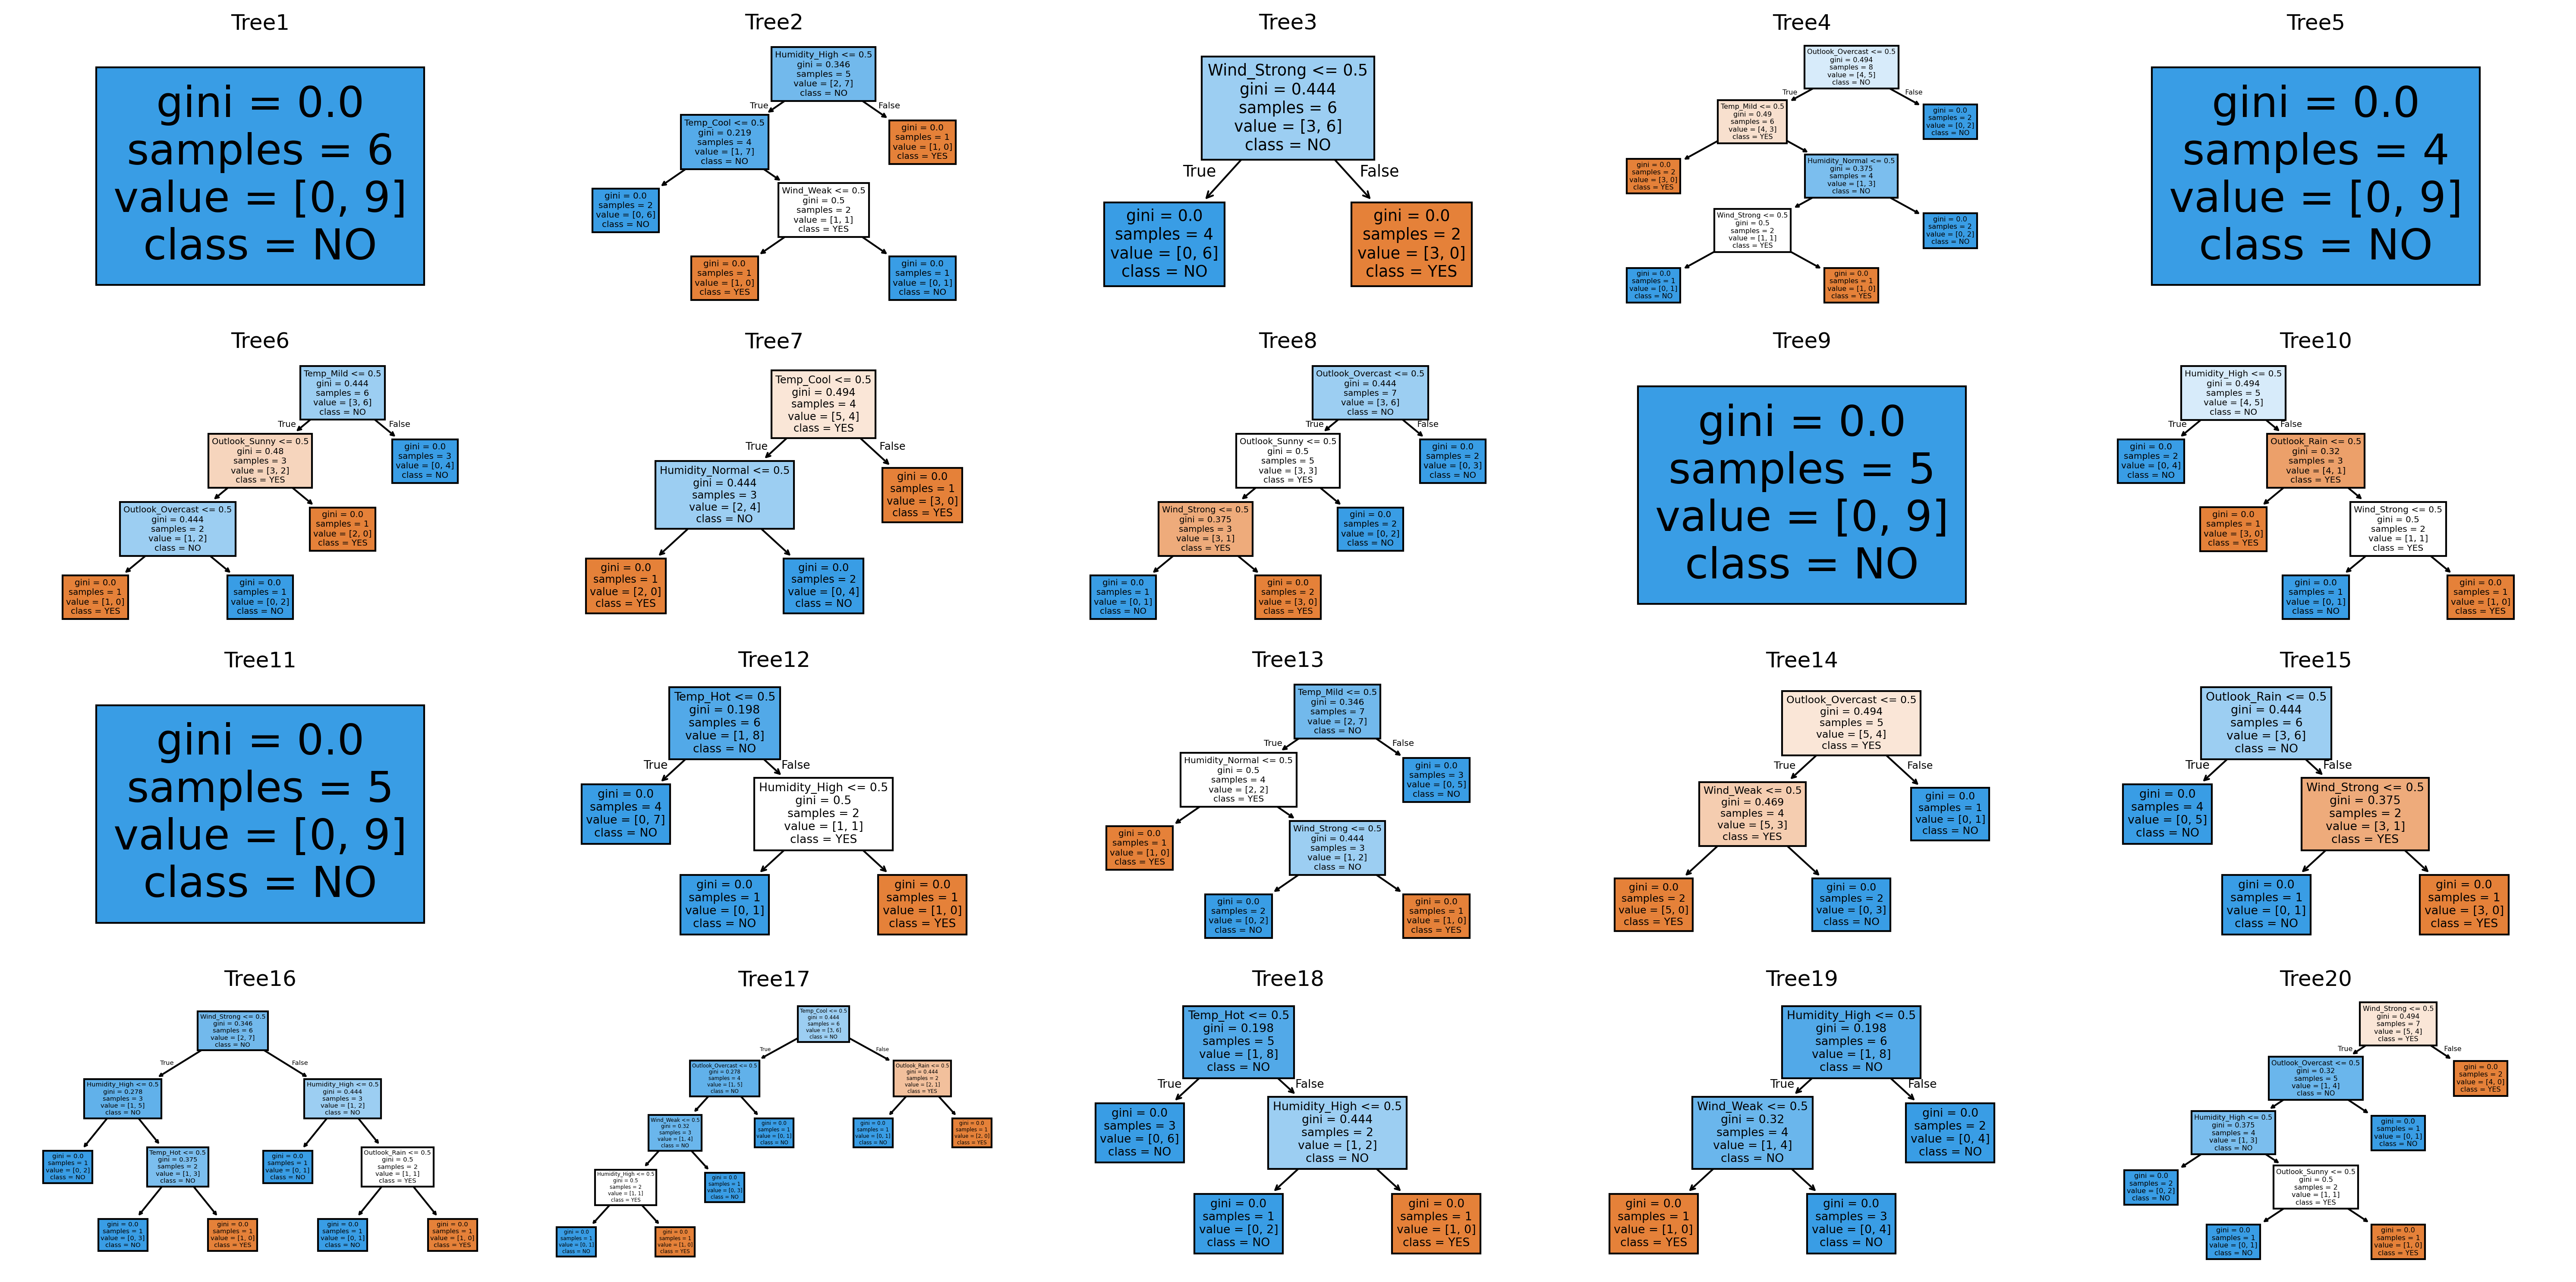

In [ ]:
# set up the figure with appropritate dimensions

num_trees = len(model.estimators_)

cols = 5

rows = (num_trees + cols -1)// cols
fig, axes = plt.subplots(rows,cols,figsize = (20,10),dpi = 300)
axes = axes.flatten()


#visualize each decison tree in the random forest

for i, tree in enumerate(model.estimators_):
    plot_tree(tree,feature_names=X.columns,class_names=['YES','NO'], filled=True, ax = axes[i])
    axes[i].set_title(f"Tree{i+1}")

# remove unused subplots 

for j in range(i+1, num_trees):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,Y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[[1 1]
 [0 3]]
              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

